In [ ]:
!pip install tensorflow matplotlib numpy scipy scikit-learn seaborn opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: shriabiju
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


100%|██████████| 157M/157M [00:08<00:00, 19.5MB/s]


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import os

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
dataset_path = './brain-tumor-mri-dataset'

for split in ['Training', 'Testing']:
    split_path = os.path.join(dataset_path, split)
    if os.path.exists(split_path):
        print(f"\n{split} set:")
        for category in sorted(os.listdir(split_path)):
            cat_path = os.path.join(split_path, category)
            if os.path.isdir(cat_path):
                count = len(os.listdir(cat_path))
                print(f"  {category}: {count} images")


Training set:
  glioma: 1400 images
  meningioma: 1400 images
  notumor: 1400 images
  pituitary: 1400 images

Testing set:
  glioma: 400 images
  meningioma: 400 images
  notumor: 400 images
  pituitary: 400 images


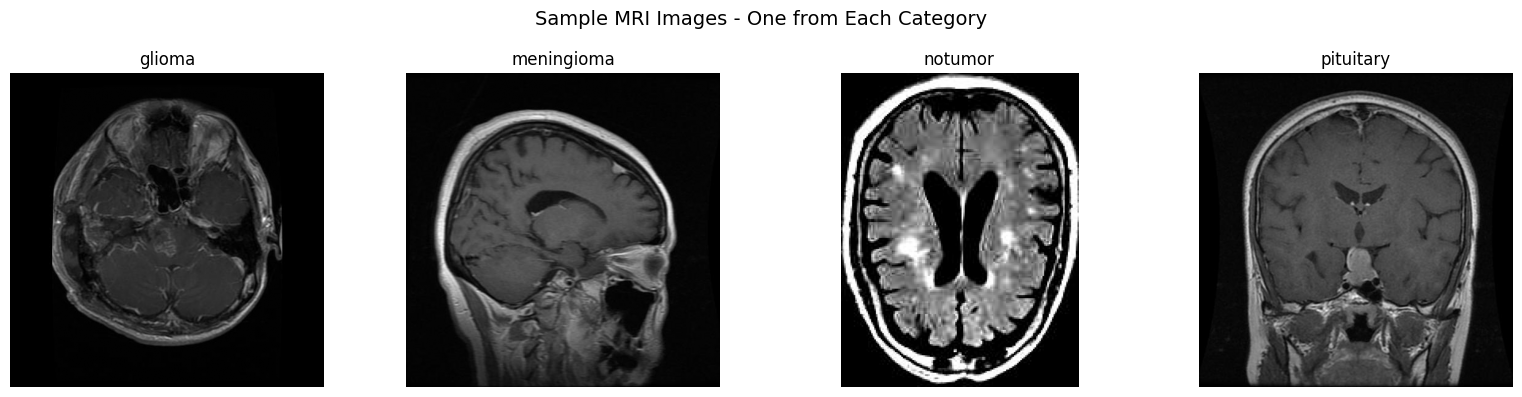

Original image size: (512, 512)
Image mode: L


In [ ]:
from PIL import Image

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, cat in enumerate(class_names):
    img_path = os.path.join('./brain-tumor-mri-dataset/Training', cat)
    img = Image.open(os.path.join(img_path, os.listdir(img_path)[5]))
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(cat, fontsize=12)
    axes[i].axis('off')
plt.suptitle("Sample MRI Images - One from Each Category", fontsize=14)
plt.tight_layout()
plt.show()

sample_path = './brain-tumor-mri-dataset/Training/glioma'
sample_img = Image.open(os.path.join(sample_path, os.listdir(sample_path)[0]))
print("Original image size:", sample_img.size)
print("Image mode:", sample_img.mode)

In [ ]:
IMG_SIZE = 128  # increased from 64 for more detail

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    shear_range=0.05,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    './brain-tumor-mri-dataset/Training',
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='rgb',          # changed to rgb
    batch_size=32,
    class_mode='sparse',
    shuffle=True
)

test_data = test_datagen.flow_from_directory(
    './brain-tumor-mri-dataset/Testing',
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='rgb',          # changed to rgb
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

print("\nClass mapping:", train_data.class_indices)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [ ]:
from tensorflow.keras.optimizers import Adam

model = models.Sequential([
    # Block 1 — 32 filters
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Block 2 — 64 filters
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Block 3 — 128 filters
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 4 — 256 filters (new)
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Classification head
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,276,324 (4.87 MB)

 Trainable params: 1,273,892 (4.86 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss', factor=0.4, patience=4, min_lr=1e-7, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1, mode='max'
)
checkpoint = ModelCheckpoint(
    'best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1
)

history = model.fit(
    train_data,
    epochs=60,
    validation_data=test_data,
    callbacks=[lr_reducer, early_stop, checkpoint]
)

Epoch 1/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.5526 - loss: 1.1703
Epoch 1: val_accuracy improved from None to 0.34813, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 66s 251ms/step - accuracy: 0.6137 - loss: 1.0141 - val_accuracy: 0.3481 - val_loss: 4.2588 - learning_rate: 0.0010
Epoch 2/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.7204 - loss: 0.7229
Epoch 2: val_accuracy improved from 0.34813 to 0.39812, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 40s 227ms/step - accuracy: 0.7302 - loss: 0.7033 - val_accuracy: 0.3981 - val_loss: 3.4557 - learning_rate: 0.0010
Epoch 3/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.7664 - loss: 0.6044
Epoch 3: val_accuracy did not improve from 0.39812
175/175 ━━━━━━━━━━━━━━━━━━━━ 39s 224ms/step - accuracy: 0.7848 - loss: 0.5727 - val_accuracy: 0.2331 - val_loss: 12.85

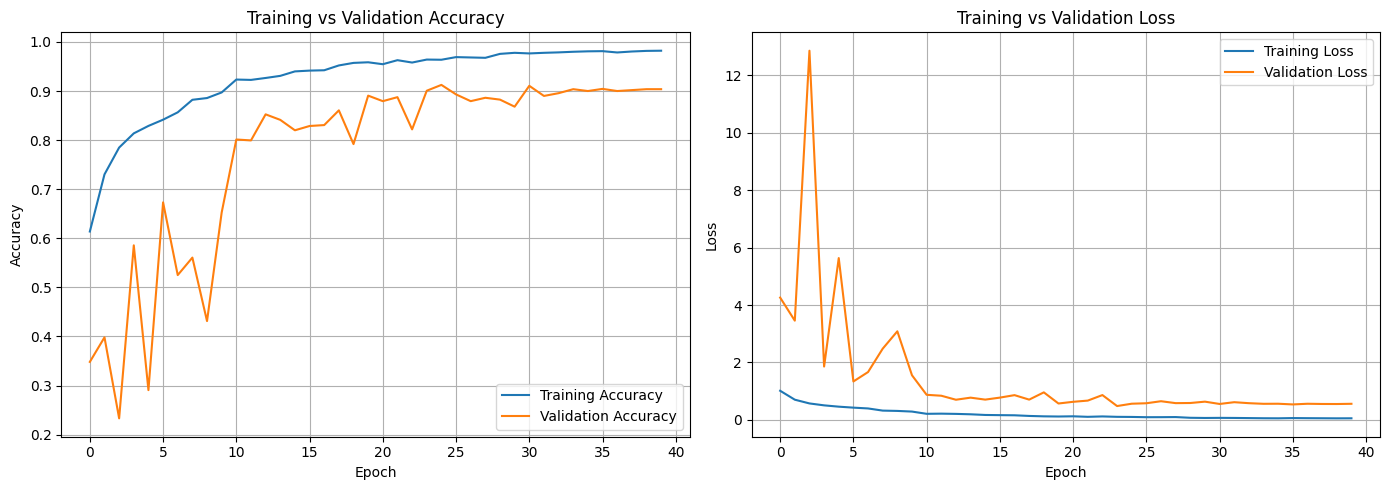


Final Training Accuracy: 98.21%
Best Validation Accuracy: 91.25%

Mild overfitting - gap is 6.96%


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Training vs Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Training vs Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nFinal Training Accuracy: {:.2f}%".format(history.history['accuracy'][-1] * 100))
print("Best Validation Accuracy: {:.2f}%".format(max(history.history['val_accuracy']) * 100))

gap = history.history['accuracy'][-1] - max(history.history['val_accuracy'])
if gap < 0.05:
    print("\nNo significant overfitting - gap is only {:.2f}%".format(gap * 100))
elif gap < 0.10:
    print("\nMild overfitting - gap is {:.2f}%".format(gap * 100))
else:
    print("\nOverfitting detected - gap is {:.2f}%".format(gap * 100))s